# 04 — Gaussian posterior: programmatic graph API

This notebook demonstrates the **Python-first** way to define a Falcon model:
build the graph with `Graph.add_node()` instead of a YAML config file.
The forward model and embedding are plain Python callables defined right here
in the notebook — no separate `src/model.py` needed.

The same model is also runnable via the CLI:
```bash
cd examples/04_gaussian
falcon launch -o output/cli_run
```
That CLI path uses `config.yml` + `src/model.py`.  Both paths produce
identical results; the notebook path is the "define your own" lesson.

**Prerequisites**: run `python data/gen_mock_data.py` once to create the
mock observation, then execute this notebook from `examples/04_gaussian/`.

## 1. Define the forward model and embedding in Python

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import falcon
from falcon.embeddings import apply


class ExpPlusNoise:
    """Forward model: x = exp(z) + noise.  Plain callable, no base class needed."""

    def __init__(self, sigma: float = 1e-6):
        self.sigma = sigma

    def simulate_batch(self, batch_size, z):
        z = torch.tensor(z)
        x = torch.exp(z) + torch.randn_like(z) * self.sigma
        return x.numpy()


class Concat(nn.Module):
    """Concatenate two observations along the last dimension."""

    def forward(self, x1, x2):
        return torch.cat([x1, x2], dim=-1)

## 2. Load the observation

In [2]:
obs = np.load("data/mock_data.npz")["x"]  # shape (3,)
print("Observation shape:", obs.shape, " values:", obs)

Observation shape: (3,)  values: [6.73794700e-03 1.00000000e+00 1.48413159e+02]


## 3. Build the graph programmatically

`falcon.Graph()` starts empty.  `add_node()` accepts live Python objects
for `simulator=` and `estimator=`; they are shipped to Ray actors via
cloudpickle — no importable path required.

In [ ]:
graph = falcon.Graph()

graph.add_node(
    "z",
    simulator=falcon.priors.Product([
        ["normal", 0.0, 1.0],
        ["normal", 0.0, 1.0],
        ["normal", 0.0, 1.0],
    ]),
    estimator=falcon.estimators.GaussianFullCov(
        max_epochs=8000,
        lr=0.01,
        gamma=0.1,
        embedding=apply(Concat, ["x1", "x2"]),
        batch_size=128,
        early_stop_patience=128,
        hidden_dim=128,
        num_layers=3,
        momentum=0.01,
        min_var=1e-20,
        eig_update_freq=1,
        lr_decay_factor=1.0,
        discard_samples=False,
        log_ratio_threshold=-20.0,
    ),
    evidence=["x1", "x2"],
    ray_num_gpus=0.5,
)

graph.add_node(
    "x1",
    simulator=ExpPlusNoise(sigma=1e-6),
    parents=["z"],
    observed=obs,
    ray_num_gpus=0.2,
)

graph.add_node(
    "x2",
    simulator=ExpPlusNoise(sigma=1e-6),
    parents=["z"],
    observed=obs,
    ray_num_gpus=0.2,
)

graph

## 4. Launch training

`falcon.launch(graph)` synthesises a default config (buffer, paths, logging),
saves it as `config.yml` in the output directory, and runs training.
Pass `overrides=` to customise buffer size or epoch count.

In [4]:
run = falcon.launch(
    graph,
    #output="output/notebook_run",
    overrides=[
        "buffer.min_samples=1024",
        "buffer.max_samples=1024",
        "buffer.validation_samples=256",
        "buffer.simulate_count=128",
        "buffer.simulate_when_full=true",
        "buffer.simulate_interval=1.001",
        "buffer.snapshot_every=10",
        "sample.posterior.n=1000",
    ],
)
run

2026-06-20T00:25:53 [INFO] falcon v0.4.3.dev29+gcec04a13e
2026-06-20T00:25:53 [INFO] Output: output/260620-002549-russet-tanuki
2026-06-20T00:25:53 [INFO] Ray: 145.136.62.24:65254 (new local instance)
2026-06-20T00:25:53 [INFO] Resources: 72 CPU, 1 GPU, 321.8 GB
2026-06-20T00:25:53 [INFO] Falcon graph structure:
  Node name          List of parents                                 Class name
* z               <-                                               | <falcon.priors.product.Product object at 0x14b4d9adfee0>
* x2              <- z                                             | <__main__.ExpPlusNoise object at 0x14b4d9adce20>
* x1              <- z                                             | <__main__.ExpPlusNoise object at 0x14b4d9adcfa0>

2026-06-20T00:25:53 [INFO] Observed: x1 [1, 3]
2026-06-20T00:25:53 [INFO] Observed: x2 [1, 3]
2026-06-20T00:25:53 [INFO] Spinning up graph...
2026-06-20T00:25:56 [INFO]   ✓ z
2026-06-20T00:25:59 [INFO]   ✓ x1
2026-06-20T00:25:59 [INFO]   ✓ x2


(DatasetManagerActor pid=1169399) Using blocking ray.get inside async actor. This blocks the event loop. Please use `await` on object ref with asyncio.gather if you want to yield execution to the event loop instead.


2026-06-20T00:26:03 [INFO] [z] Training started
2026-06-20T00:26:05 [INFO] ============================================================
2026-06-20T00:26:05 [INFO] falcon launch failed (RayTaskError(TypeError): ray::NodeWrapper.train() (pid=1169389, ip=145.136.62.24, actor_id=1ffd355c0e58f60b3d62c2fa01000000, repr=<falcon.core.deployed_graph.NodeWrapper object at 0x14c8489b8130>)
  File "/home/weniger/.conda/envs/emri_few_timm/lib/python3.10/concurrent/futures/_base.py", line 438, in result
    return self.__get_result()
  File "/home/weniger/.conda/envs/emri_few_timm/lib/python3.10/concurrent/futures/_base.py", line 390, in __get_result
    raise self._exception
  File "/gpfs/home2/weniger/falcon/falcon/core/deployed_graph.py", line 218, in train
    await self.estimator_instance.train(buffer)
  File "/gpfs/home2/weniger/falcon/falcon/estimators/stepwise_base.py", line 143, in train
    await self._train(buffer, keys)
  File "/gpfs/home2/weniger/falcon/falcon/estimators/stepwise_base.p

RayTaskError(TypeError): [36mray::NodeWrapper.train()[39m (pid=1169389, ip=145.136.62.24, actor_id=1ffd355c0e58f60b3d62c2fa01000000, repr=<falcon.core.deployed_graph.NodeWrapper object at 0x14c8489b8130>)
  File "/home/weniger/.conda/envs/emri_few_timm/lib/python3.10/concurrent/futures/_base.py", line 438, in result
    return self.__get_result()
  File "/home/weniger/.conda/envs/emri_few_timm/lib/python3.10/concurrent/futures/_base.py", line 390, in __get_result
    raise self._exception
  File "/gpfs/home2/weniger/falcon/falcon/core/deployed_graph.py", line 218, in train
    await self.estimator_instance.train(buffer)
  File "/gpfs/home2/weniger/falcon/falcon/estimators/stepwise_base.py", line 143, in train
    await self._train(buffer, keys)
  File "/gpfs/home2/weniger/falcon/falcon/estimators/stepwise_base.py", line 175, in _train
    metrics = self.train_step(batch)
  File "/gpfs/home2/weniger/falcon/falcon/estimators/gaussian_fullcov.py", line 420, in train_step
    self._initi

## 5. Inspect the saved config

The saved `config.yml` is human-readable; live Python objects appear as
`<live object: ClassName>` placeholders so the file is honest about
reproducibility.

In [5]:
cfg_path = run.run_dir / "config.yml"
print(cfg_path.read_text())

logging:
  local:
    enabled: true
    dir: output/260620-002403-inescapable-oriole/graph
paths:
  imports: []
  graph: output/260620-002403-inescapable-oriole/graph
  samples: output/260620-002403-inescapable-oriole/samples
buffer:
  min_samples: 1024
  max_samples: 1024
  validation_samples: 256
  simulate_count: 128
  simulate_when_full: true
  simulate_interval: 1.001
  snapshot_every: 10
sample:
  posterior:
    'n': 1000
graph:
  z:
    evidence:
    - x
    simulator: '<live object: Product>'
    estimator: '<live object: GaussianFullCov>'
    ray:
      num_gpus: 0.5
  x:
    parents:
    - z
    simulator: '<live object: ExpPlusNoise>'
    observed: '<live array: shape=[3], dtype=float64>'
    ray:
      num_gpus: 0.5
run_dir: output/260620-002403-inescapable-oriole



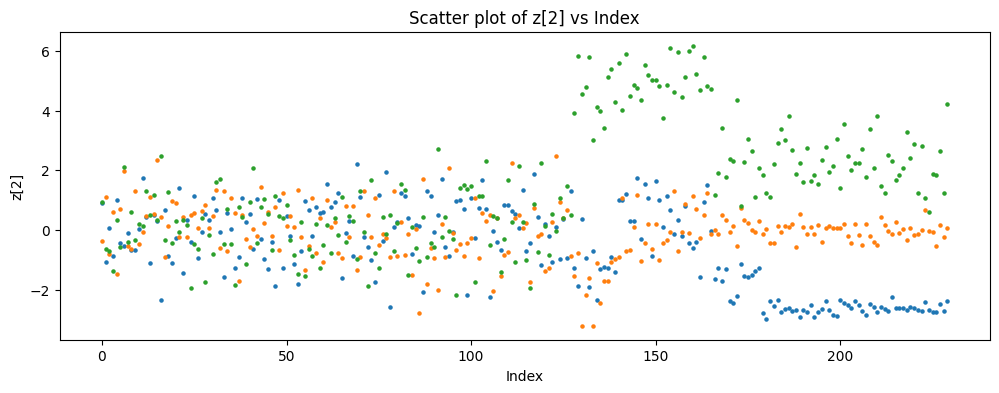

In [6]:
z = run.buffer.stacked['z.value']
import pylab as plt
# Plot scatter plot as function of index for all three dimensions
plt.figure(figsize=(12, 4))
for i in range(3):
    #plt.subplot(1, 3, i + 1)
    plt.scatter(range(len(z)), z[:, i], s=5)
    plt.xlabel("Index")
    plt.ylabel(f"z[{i}]")
    plt.title(f"Scatter plot of z[{i}] vs Index")